In [1]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\heman\Downloads\train.csv",usecols=["Survived","Age","Fare"])

In [3]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [5]:
x=df[["Age","Fare"]]
y=df["Survived"]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train,x_test,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
x_train["Age_imputed"]=x_train["Age"]
x_test["Age_imputed"]=x_test["Age"]

C:\Users\heman\AppData\Local\Temp\ipykernel_7816\4091101346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train["Age_imputed"]=x_train["Age"]
C:\Users\heman\AppData\Local\Temp\ipykernel_7816\4091101346.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test["Age_imputed"]=x_test["Age"]


In [9]:
x_train.sample(5)

,Age,Fare,Age_imputed
265,36.0,10.500,36.0
429,32.0,8.050,32.0
393,23.0,113.275,23.0
157,30.0,8.050,30.0
203,45.5,7.225,45.5


In [10]:
x_train["Age_imputed"][x_train["Age_imputed"].isnull()]=x_train["Age"].dropna().sample(x_train["Age"].isnull().sum()).values
x_test["Age_imputed"][x_test["Age_imputed"].isnull()]=x_test["Age"].dropna().sample(x_test["Age"].isnull().sum()).values

C:\Users\heman\AppData\Local\Temp\ipykernel_7816\2967098619.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train["Age_imputed"][x_train["Age_imputed"].isnull()]=x_train["Age"].dropna().sample(x_train["Age"].isnull().sum()).values
C:\U

In [11]:
x_train.isnull().sum()

Age            140
Fare             0
Age_imputed      0
dtype: int64

In [12]:
x_train["Age"].dropna().sample(x_train["Age"].isnull().sum()).values

array([21. ,  6. , 25. , 28. , 32.5, 55. , 19. , 21. , 21. , 44. , 41. ,
       27. , 51. , 18. , 45. , 42. , 19. , 18. , 45. , 29. , 34. , 36. ,
        3. , 70. , 23. , 24. , 31. , 28. , 46. , 62. , 49. , 10. , 45. ,
       17. ,  1. , 29. , 32. , 22. , 44. , 46. , 18. , 33. , 22. ,  8. ,
       39. , 17. , 32. , 50. , 50. , 55. , 32. , 42. , 58. , 62. , 30. ,
       24. , 22. , 35. , 27. , 21. , 18. , 28. , 24. ,  9. , 35. , 35. ,
       60. , 25. , 19. , 40. , 40.5, 27. , 24. , 21. , 15. , 23. , 54. ,
       16. , 24. , 45. , 31. , 18. , 20. , 51. ,  2. , 30. , 28. , 21. ,
       38. , 49. , 27. ,  4. , 27. , 21. , 32. , 62. , 22. , 17. , 28. ,
       22. , 22. , 32.5, 26. , 28. , 34. , 23. , 25. , 17. , 26. , 58. ,
       20. , 21. , 14.5, 35. , 38. , 39. , 21. , 35. , 65. , 26. , 36. ,
       24. , 54. , 40. , 29. , 36. , 47. , 30. , 29. , 61. , 52. , 36. ,
       56. , 12. , 44. , 26. , 24. , 22. , 18. , 33. ])

In [13]:
x_train["Age"].isnull().sum()

140

In [14]:
x_train.cov()

,Age,Fare,Age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,56.957873
Age_imputed,210.251707,56.957873,215.642490


C:\Users\heman\AppData\Local\Temp\ipykernel_7816\4219133863.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Age"],label="original",hist=False)
C:\Users\heman\AppData\Local\Temp\ipykernel_7816\4219133863.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["A

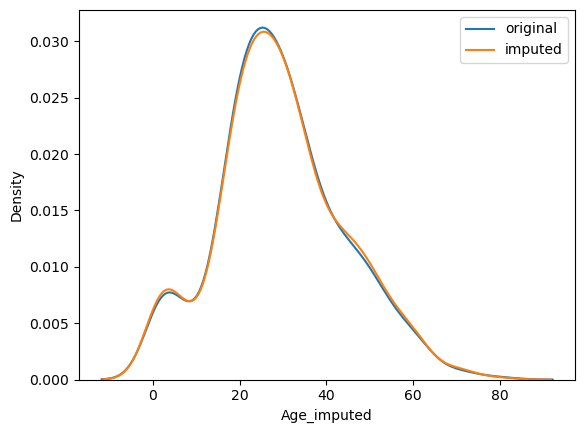

In [15]:
sns.distplot(x_train["Age"],label="original",hist=False)
sns.distplot(x_train["Age_imputed"],label="imputed",hist=False)
plt.legend()
plt.show()

C:\Users\heman\AppData\Local\Temp\ipykernel_7816\3024054188.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test["Age"],label="original",hist=False)
C:\Users\heman\AppData\Local\Temp\ipykernel_7816\3024054188.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test["Age

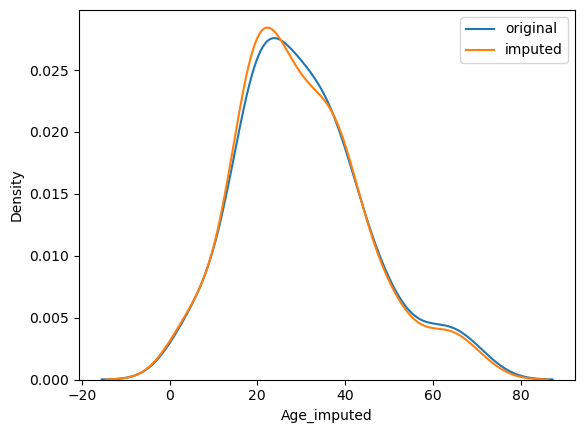

In [16]:
sns.distplot(x_test["Age"],label="original",hist=False)
sns.distplot(x_test["Age_imputed"],label="imputed",hist=False)
plt.legend()
plt.show()

In [17]:
print(x_train["Age"].var())
print(x_train["Age_imputed"].var())

210.2517072477438
215.64248959291388


<AxesSubplot:>

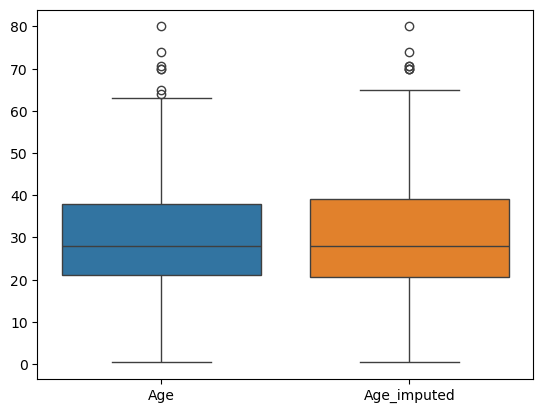

In [18]:
sns.boxplot(x_train[["Age","Age_imputed"]])

In [19]:
sample_value=x_train["Age"].dropna().sample(1)

In [20]:
sample_value

142    24.0
Name: Age, dtype: float64

In [21]:
df1=pd.read_csv(r"C:\Users\heman\Downloads\train (1).csv",usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [22]:
df1

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [23]:
df1.isnull().sum()

FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

In [24]:
df1["FireplaceQu_imputed"]=df1["FireplaceQu"]
df1["GarageQual_imputed"]=df1["GarageQual"]

In [28]:
df1["FireplaceQu_imputed"][df1["FireplaceQu_imputed"].isnull().sum()]=df1["FireplaceQu"].dropna().sample(df1["FireplaceQu"].isnull().sum()).values

C:\Users\heman\AppData\Local\Temp\ipykernel_7816\4205687060.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df1["FireplaceQu_imputed"][df1["FireplaceQu_imputed"].isnull().sum()]=df1["FireplaceQu"].dropna().sample(df1["FireplaceQu"].isnul

In [31]:
df1["GarageQual_imputed"][df1["GarageQual_imputed"].isnull().sum()]=df1["GarageQual"].dropna().sample(df1["GarageQual"].isnull().sum())

C:\Users\heman\AppData\Local\Temp\ipykernel_7816\3658888364.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df1["GarageQual_imputed"][df1["GarageQual_imputed"].isnull().sum()]=df1["GarageQual"].dropna().sample(df1["GarageQual"].isnull().